<a href="https://colab.research.google.com/github/RegiRezende/MathCode/blob/main/SOL_SIMPLIF_1D_CALOR_TRANSIENTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[100.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.]


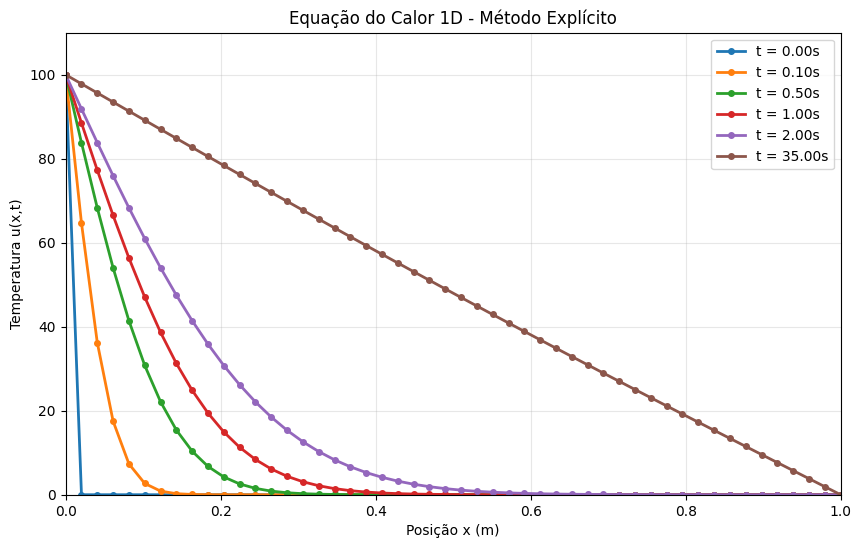

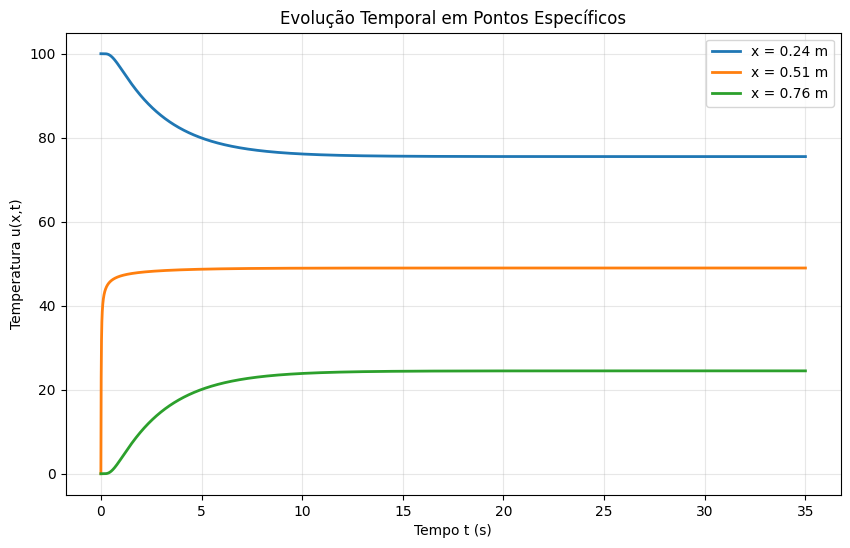

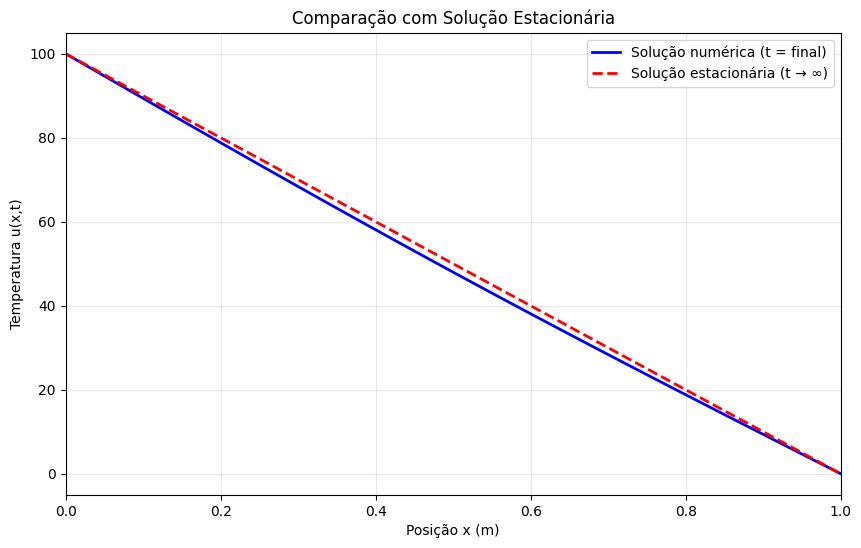

Simulação concluída!
Parâmetro de estabilidade r = 0.0240 (estável)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
L = 1.0                 # comprimento da barra
nx = 50                # pontos espaciais
dx = L/(nx-1)           # espaçamento
alpha = 0.01           # difusividade
t_final = 35           # tempo final

# Condição de estabilidade
#dt = 0.4*dx**2/alpha    # passo de tempo
#nt = int(t_final/dt)+1  # passos no tempo
#r = alpha*dt/dx**2      # parâmetro,sempre =0.4 (sempre estável)

dt = 0.001               # valor fixo em segundos
nt = int(t_final/dt)+1  # passos no tempo
r = alpha * dt / dx**2  # este r vai variar com nx


# Malhas
x = np.linspace(0, L, nx)
u = np.zeros(nx)
u_nova = np.zeros(nx)

# Condição inicial (degrau)
#u[:nx//2] = 100.0
#u[nx//2:] = 0.0
# Condições de contorno fixas
u[0] = 100.0      # borda esquerda
u[-1] = 0.0       # borda direita
print(u)
# Para salvar resultados nos tempos desejados
tempos_salvar = [0, 0.1, 0.5, 1.0, 2.0]
indices_salvar = [int(t/dt) for t in tempos_salvar if int(t/dt) < nt]
solucao = [u.copy()]  # começa com t=0

# Loop no tempo
u_nova = u.copy()
for n in range(1, nt):
    #u_nova = u.copy()

    # Pontos internos
    for i in range(1, nx-1):
        u_nova[i] = u[i] + r*(u[i+1] - 2*u[i] + u[i-1])

    # Aplicar condições de contorno
    #u_nova[0] = 100.0
    #u_nova[-1] = 0.0

    u = u_nova.copy()

    # Salvar nos instantes desejados
    if n in indices_salvar:
        solucao.append(u.copy())

# Adicionar solução final se não foi salva
if nt-1 not in indices_salvar:
    solucao.append(u.copy())
    tempos_salvar.append(t_final)

# GRÁFICO FINAL
plt.figure(figsize=(10, 6))
for i, temp in enumerate(solucao):
    plt.plot(x, temp, 'o-', linewidth=2, markersize=4,
             label=f't = {tempos_salvar[i]:.2f}s')

plt.xlabel('Posição x (m)')
plt.ylabel('Temperatura u(x,t)')
plt.title('Equação do Calor 1D - Método Explícito')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, L)
plt.ylim(0, 110)
plt.show()

# GRÁFICO DA EVOLUÇÃO EM PONTOS ESPECÍFICOS
plt.figure(figsize=(10, 6))
pontos = [nx//4, nx//2, 3*nx//4]  # x = L/4, L/2, 3L/4

for idx in pontos:
    # Recalcular evolução temporal para este ponto
    u_temp = np.zeros(nt)
    u_temp[0] = 100.0 if idx < nx//2 else 0.0

    # Reexecutar simulação simplificada para este ponto
    u_atual = np.zeros(nx)
    u_atual[:nx//2] = 100.0
    u_atual[nx//2:] = 0.0
    u_atual[0] = 100.0
    u_atual[-1] = 0.0

    for n in range(1, nt):
        u_novo = u_atual.copy()
        for i in range(1, nx-1):
            u_novo[i] = u_atual[i] + r*(u_atual[i+1] - 2*u_atual[i] + u_atual[i-1])
        u_novo[0] = 100.0
        u_novo[-1] = 0.0
        u_atual = u_novo.copy()
        u_temp[n] = u_atual[idx]

    t = np.linspace(0, t_final, nt)
    plt.plot(t, u_temp, linewidth=2, label=f'x = {x[idx]:.2f} m')

plt.xlabel('Tempo t (s)')
plt.ylabel('Temperatura u(x,t)')
plt.title('Evolução Temporal em Pontos Específicos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# GRÁFICO DA SOLUÇÃO FINAL VS ESTACIONÁRIA
plt.figure(figsize=(10, 6))
u_estacionario = 100 * (1 - x/L)  # solução linear para t→∞
plt.plot(x, u, 'b-', linewidth=2, label='Solução numérica (t = final)')
plt.plot(x, u_estacionario, 'r--', linewidth=2, label='Solução estacionária (t → ∞)')
plt.xlabel('Posição x (m)')
plt.ylabel('Temperatura u(x,t)')
plt.title('Comparação com Solução Estacionária')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, L)
plt.show()

print(f'Simulação concluída!')
print(f'Parâmetro de estabilidade r = {r:.4f} {"(estável)" if r<=0.5 else "(instável!)"}')